# 🏦 Bank Cash Optimization — Feature Engineering

---

**Project:** Bank Cash Optimization  
**Notebook:** 02_Feature_Engineering  



##  Objective

This notebook transforms the **raw banking dataset** into a **model-ready feature matrix** for Machine Learning.  
All design decisions are based on findings from the EDA notebook.

**This notebook covers:**
1. Data loading & quality remediation (missing values, duplicates, outliers)
2. Data type correction
3. Date & time feature extraction
4. Banking domain feature engineering
5. Aggregation-based features (branch, hourly, daily, monthly)
6. Feature scaling
7. Feature selection
8. Final dataset preview and summary




---
## Step 1 — Load the Cleaned Dataset

We load the raw dataset directly. Data cleaning decisions made here are documented with business justifications — this notebook serves as the **data transformation record** for audit purposes.


In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ───────────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

# ── Display Configuration ─────────────────────────────────────────────────────
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 150)

plt.rcParams['figure.figsize']  = (14, 5)
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.labelsize']  = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

BANK_PALETTE = ['#1F4E79', '#2E75B6', '#A9C4E2', '#D6462B', '#F4A460']
sns.set_palette(BANK_PALETTE)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
# ── Load Dataset ───────────────────────────────────────────────────────────────
df = pd.read_excel('Bank Cash Optimization.xlsx')

# Ensure correct datetime type for start_date
df['start_date'] = pd.to_datetime(df['start_date'])

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Columns : {df.columns.tolist()}")
print(f"   Date Range: {df['start_date'].min().date()} → {df['start_date'].max().date()}")
df.head(5)

✅ Dataset loaded: 81,717 rows × 5 columns
   Columns : ['start_date', 'txn_hour', 'tran_br_code', 'TOTAL_DR', 'TOTAL_CR']
   Date Range: 2024-01-02 → 2026-04-04


,start_date,txn_hour,tran_br_code,TOTAL_DR,TOTAL_CR
0,2026-03-07,14,1046,14400000,10971992
1,2024-11-12,13,1046,16280280,7700344
2,2025-05-15,15,287,8700118,6046617
3,2025-08-20,13,1092,6688531,4895120
4,2024-11-22,13,202,0,10969592


---
## Step 2 — Handle Missing Values

### Decision Rationale
EDA confirmed **zero missing values** in this dataset. However, we implement a programmatic check here to future-proof the pipeline — in production, new data batches may arrive with nulls from ETL failures or system downtime.


In [3]:
# ── 2.1 Missing Values Check ───────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Column'        : missing.index,
    'Missing Count' : missing.values,
    'Missing %'     : missing_pct.values.round(2)
})
print("🔍 Missing Value Report:")
print(missing_report.to_string(index=False))

🔍 Missing Value Report:
      Column  Missing Count  Missing %
  start_date              0     0.0000
    txn_hour              0     0.0000
tran_br_code              0     0.0000
    TOTAL_DR              0     0.0000
    TOTAL_CR              0     0.0000


In [4]:
# ── 2.2 Missing Value Handling Strategy ───────────────────────────────────────
if missing.sum() == 0:
    print("✅ No missing values detected. No imputation required.")
else:
    # Strategy for each column type:
    # - Monetary columns (TOTAL_DR, TOTAL_CR): Median imputation (robust to outliers)
    # - txn_hour: Mode imputation (most frequent hour)
    # - tran_br_code: Flag as 'UNKNOWN' and investigate source
    # - start_date: Forward fill (banking data is sequential)
    
    for col in ['TOTAL_DR', 'TOTAL_CR']:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"   {col}: Filled {df[col].isnull().sum()} nulls with median ({median_val:,.0f})")
    
    if df['txn_hour'].isnull().sum() > 0:
        mode_val = df['txn_hour'].mode()[0]
        df['txn_hour'].fillna(mode_val, inplace=True)
        print(f"   txn_hour: Filled with mode ({mode_val})")
    
    if df['start_date'].isnull().sum() > 0:
        df['start_date'].fillna(method='ffill', inplace=True)
        print("   start_date: Forward-filled missing dates")

print(f"\n✅ Post-handling missing values: {df.isnull().sum().sum()}")

✅ No missing values detected. No imputation required.

✅ Post-handling missing values: 0


---
## Step 3 — Handle Duplicate Records

### Decision Rationale
Duplicates in banking data are serious — they can lead to **double-counting of cash** in optimization models.  
We check both exact row duplicates and business-key duplicates (same branch + date + hour).


In [5]:
# ── 3.1 Duplicate Detection ────────────────────────────────────────────────────
exact_dups  = df.duplicated().sum()
biz_key_dups = df.duplicated(subset=['start_date', 'txn_hour', 'tran_br_code']).sum()

print(f"🔍 Duplicate Analysis:")
print(f"   Exact Row Duplicates               : {exact_dups:,}")
print(f"   Business-Key Duplicates            : {biz_key_dups:,}")
print(f"   (Business Key = date + hour + branch)")

🔍 Duplicate Analysis:
   Exact Row Duplicates               : 8
   Business-Key Duplicates            : 8
   (Business Key = date + hour + branch)


In [6]:
# ── 3.2 Remove Duplicates ─────────────────────────────────────────────────────
rows_before = len(df)

# Remove exact row duplicates
df.drop_duplicates(inplace=True)
rows_after_exact = len(df)

# For business-key duplicates: keep the record with higher total cash movement
# (strategy: max DR + CR wins — assumes the larger value is the correct consolidated record)
df['_total_cash'] = df['TOTAL_DR'] + df['TOTAL_CR']
df = df.sort_values('_total_cash', ascending=False)
df = df.drop_duplicates(subset=['start_date', 'txn_hour', 'tran_br_code'], keep='first')
df = df.drop(columns=['_total_cash'])
df.reset_index(drop=True, inplace=True)

rows_after_all = len(df)
print(f"✅ Duplicate Removal Summary:")
print(f"   Rows Before              : {rows_before:,}")
print(f"   After Exact Dedup        : {rows_after_exact:,} (removed {rows_before - rows_after_exact:,})")
print(f"   After Business-Key Dedup : {rows_after_all:,} (removed {rows_after_exact - rows_after_all:,})")
print(f"   Final Dataset Size       : {rows_after_all:,} rows")

✅ Duplicate Removal Summary:
   Rows Before              : 81,717
   After Exact Dedup        : 81,709 (removed 8)
   After Business-Key Dedup : 81,709 (removed 0)
   Final Dataset Size       : 81,709 rows


---
## Step 4 — Handle Outliers

### Decision Rationale
EDA confirmed that outliers in this dataset represent **genuine high-value banking transactions** (corporate payments, bulk salaries, inter-bank settlements) — not data errors.  

**Strategy: Winsorization (Capping at 1st and 99th Percentile)**  
- We do NOT remove outliers (would lose real business events)
- We cap extreme values at the 1st and 99th percentile
- This prevents a handful of extreme values from dominating ML model gradients
- Original values are preserved in `TOTAL_DR_raw` and `TOTAL_CR_raw` columns for reporting


In [7]:
# ── 4.1 Preserve Raw Values ────────────────────────────────────────────────────
df['TOTAL_DR_raw'] = df['TOTAL_DR'].copy()
df['TOTAL_CR_raw'] = df['TOTAL_CR'].copy()

# ── 4.2 Calculate Winsorization Bounds ────────────────────────────────────────
p01_dr, p99_dr = df['TOTAL_DR'].quantile(0.01), df['TOTAL_DR'].quantile(0.99)
p01_cr, p99_cr = df['TOTAL_CR'].quantile(0.01), df['TOTAL_CR'].quantile(0.99)

print("📊 Winsorization Bounds:")
print(f"   TOTAL_DR — Cap at: {p01_dr/1e6:.2f}M (1st pct) to {p99_dr/1e6:.2f}M (99th pct)")
print(f"   TOTAL_CR — Cap at: {p01_cr/1e6:.2f}M (1st pct) to {p99_cr/1e6:.2f}M (99th pct)")

# ── 4.3 Apply Winsorization ───────────────────────────────────────────────────
df['TOTAL_DR'] = df['TOTAL_DR'].clip(lower=p01_dr, upper=p99_dr)
df['TOTAL_CR'] = df['TOTAL_CR'].clip(lower=p01_cr, upper=p99_cr)

dr_affected = (df['TOTAL_DR'] != df['TOTAL_DR_raw']).sum()
cr_affected = (df['TOTAL_CR'] != df['TOTAL_CR_raw']).sum()

print(f"\n✅ Winsorization Applied:")
print(f"   TOTAL_DR: {dr_affected:,} values capped ({100*dr_affected/len(df):.1f}%)")
print(f"   TOTAL_CR: {cr_affected:,} values capped ({100*cr_affected/len(df):.1f}%)")

# ── 4.4 Flag High-Value Transactions (for ML signal) ──────────────────────────
df['Is_High_Value_DR'] = (df['TOTAL_DR_raw'] > p99_dr).astype(int)
df['Is_High_Value_CR'] = (df['TOTAL_CR_raw'] > p99_cr).astype(int)

print(f"\n   High-Value DR flag: {df['Is_High_Value_DR'].sum():,} transactions")
print(f"   High-Value CR flag: {df['Is_High_Value_CR'].sum():,} transactions")

📊 Winsorization Bounds:
   TOTAL_DR — Cap at: 0.00M (1st pct) to 52.04M (99th pct)
   TOTAL_CR — Cap at: 0.00M (1st pct) to 55.38M (99th pct)

✅ Winsorization Applied:
   TOTAL_DR: 818 values capped (1.0%)
   TOTAL_CR: 818 values capped (1.0%)

   High-Value DR flag: 818 transactions
   High-Value CR flag: 818 transactions


---
## Step 5 — Correct Data Types

### Decision Rationale
Correct data types are crucial for:  
- Memory efficiency (reducing RAM usage)
- Correct behavior of ML algorithms (categorical vs. ordinal encoding)
- Prevention of accidental mathematical operations on identifier columns


In [8]:
# ── 5.1 Pre-conversion Type Check ────────────────────────────────────────────
print("📊 Data Types Before Correction:")
print(df[['start_date', 'txn_hour', 'tran_br_code', 'TOTAL_DR', 'TOTAL_CR']].dtypes)
print(f"\n   Memory Usage Before: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📊 Data Types Before Correction:
start_date      datetime64[ns]
txn_hour                 int64
tran_br_code             int64
TOTAL_DR               float64
TOTAL_CR               float64
dtype: object

   Memory Usage Before: 5.61 MB


In [9]:
# ── 5.2 Apply Type Corrections ────────────────────────────────────────────────

# tran_br_code → category (it's a nominal identifier, NOT numeric)
df['tran_br_code'] = df['tran_br_code'].astype('category')

# txn_hour → uint8 (0–23 fits in 1 byte, saves memory)
df['txn_hour'] = df['txn_hour'].astype('uint8')

# start_date → already datetime64, keep as is
df['start_date'] = pd.to_datetime(df['start_date'])

# TOTAL_DR, TOTAL_CR → float32 (after winsorization, float is appropriate)
df['TOTAL_DR'] = df['TOTAL_DR'].astype('float32')
df['TOTAL_CR'] = df['TOTAL_CR'].astype('float32')

print("📊 Data Types After Correction:")
print(df[['start_date', 'txn_hour', 'tran_br_code', 'TOTAL_DR', 'TOTAL_CR']].dtypes)
print(f"\n   Memory Usage After : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n✅ Data types corrected successfully.")

📊 Data Types After Correction:
start_date      datetime64[ns]
txn_hour                 uint8
tran_br_code          category
TOTAL_DR               float32
TOTAL_CR               float32
dtype: object

   Memory Usage After : 3.90 MB

✅ Data types corrected successfully.


---
## Step 6 — Create Date Features

### Business Context
Date features capture **temporal patterns** in cash demand. Each feature carries distinct predictive power:  
- `Year`: Captures growth trends  
- `Month`: Captures seasonality (Eid, year-end)  
- `Day`: Captures month-end salary effects  
- `Weekday`: Captures weekly business cycles  
- `Quarter`: Captures quarterly financial reporting cycles  
- `Week_Number`: Captures bi-weekly payroll patterns  
- `Is_Weekend`: Binary flag separating business days from non-working days


In [10]:
# ── 6.1 Extract Date Features ─────────────────────────────────────────────────
df['Year']        = df['start_date'].dt.year.astype('int16')
df['Month']       = df['start_date'].dt.month.astype('uint8')
df['Day']         = df['start_date'].dt.day.astype('uint8')
df['Weekday']     = df['start_date'].dt.dayofweek.astype('uint8')   # 0=Monday, 6=Sunday
df['Quarter']     = df['start_date'].dt.quarter.astype('uint8')
df['Week_Number'] = df['start_date'].dt.isocalendar().week.astype('uint8')
df['Is_Weekend']  = (df['Weekday'] >= 5).astype('uint8')           # 1=Sat/Sun

print("✅ Date features created:")
date_feat_cols = ['Year','Month','Day','Weekday','Quarter','Week_Number','Is_Weekend']
print(df[['start_date'] + date_feat_cols].head(8).to_string(index=False))
print(f"\n   Is_Weekend distribution: {df['Is_Weekend'].value_counts().to_dict()}")

✅ Date features created:


start_date  Year  Month  Day  Weekday  Quarter  Week_Number  Is_Weekend
2025-12-01  2025     12    1        0        4           49           0
2026-03-24  2026      3   24        1        1           13           0
2024-02-02  2024      2    2        4        1            5           0
2024-04-15  2024      4   15        0        2           16           0
2026-03-25  2026      3   25        2        1           13           0
2026-03-25  2026      3   25        2        1           13           0
2024-12-05  2024     12    5        3        4           49           0
2024-03-07  2024      3    7        3        1           10           0

   Is_Weekend distribution: {0: 77369, 1: 4340}


---
## Step 7 — Create Time Features

### Business Context
Granular time features convert the raw `txn_hour` (0–23) into **interpretable banking time windows** that align with operational reality:  
- **Morning (6–11)**: Branch opening, early transactions  
- **Afternoon (12–15)**: Peak banking hours  
- **Evening (16–19)**: Post-lunch, closing transactions  
- **Night (20–5)**: ATM/digital only  
- **Business Hour Flag**: 9–17 (standard banking hours)  
- **Peak Hour Flag**: Hours identified in EDA as highest debit demand


In [11]:
# ── 7.1 Time Period Labels ─────────────────────────────────────────────────────
def assign_time_period(hour):
    """Assign a time period label based on hour of day."""
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 16:
        return 'Afternoon'
    elif 16 <= hour < 20:
        return 'Evening'
    else:
        return 'Night'

df['Time_Period'] = df['txn_hour'].apply(assign_time_period).astype('category')

# ── 7.2 Business Hour Flag ────────────────────────────────────────────────────
# Standard banking hours: 9 AM – 5 PM (17:00)
df['Is_Business_Hour'] = ((df['txn_hour'] >= 9) & (df['txn_hour'] < 17)).astype('uint8')

# ── 7.3 Peak Hour Flag ────────────────────────────────────────────────────────
# Based on EDA: Peak hours are 11 AM – 3 PM (highest transaction volume and debit)
df['Is_Peak_Hour'] = ((df['txn_hour'] >= 11) & (df['txn_hour'] <= 15)).astype('uint8')

# ── 7.4 Hour Sine/Cosine Encoding (for cyclical ML features) ─────────────────
# Captures the cyclical nature of time (hour 23 is close to hour 0)
df['Hour_Sin'] = np.sin(2 * np.pi * df['txn_hour'] / 24).astype('float32')
df['Hour_Cos'] = np.cos(2 * np.pi * df['txn_hour'] / 24).astype('float32')

print("✅ Time features created:")
time_cols = ['txn_hour', 'Time_Period', 'Is_Business_Hour', 'Is_Peak_Hour', 'Hour_Sin', 'Hour_Cos']
print(df[time_cols].drop_duplicates('txn_hour').sort_values('txn_hour').to_string(index=False))

✅ Time features created:
 txn_hour Time_Period  Is_Business_Hour  Is_Peak_Hour  Hour_Sin  Hour_Cos
        0       Night                 0             0    0.0000    1.0000
        8     Morning                 0             0    0.8660   -0.5000
        9     Morning                 1             0    0.7071   -0.7071
       10     Morning                 1             0    0.5000   -0.8660
       11     Morning                 1             1    0.2588   -0.9659
       12   Afternoon                 1             1    0.0000   -1.0000
       13   Afternoon                 1             1   -0.2588   -0.9659
       14   Afternoon                 1             1   -0.5000   -0.8660
       15   Afternoon                 1             1   -0.7071   -0.7071
       16     Evening                 1             0   -0.8660   -0.5000
       17     Evening                 0             0   -0.9659   -0.2588
       18     Evening                 0             0   -1.0000   -0.0000
       19    

In [12]:
# ── 7.5 Time Period Distribution Check ────────────────────────────────────────
tp_dist = df['Time_Period'].value_counts()
print("\n📊 Time Period Distribution:")
for period, count in tp_dist.items():
    pct = 100 * count / len(df)
    print(f"   {period:<12}: {count:>7,} records ({pct:.1f}%)")

print(f"\n   Business Hours records : {df['Is_Business_Hour'].sum():,} ({100*df['Is_Business_Hour'].mean():.1f}%)")
print(f"   Peak Hours records     : {df['Is_Peak_Hour'].sum():,} ({100*df['Is_Peak_Hour'].mean():.1f}%)")


📊 Time Period Distribution:
   Afternoon   :  34,760 records (42.5%)
   Morning     :  26,410 records (32.3%)
   Evening     :  19,985 records (24.5%)
   Night       :     554 records (0.7%)

   Business Hours records : 68,716 (84.1%)
   Peak Hours records     : 43,732 (53.5%)


---
## Step 8 — Create Banking Domain Features

### Business Context
These features are derived directly from domain knowledge about **banking cash dynamics**.  
They encode relationships that a raw ML algorithm cannot discover without feature engineering.

Each feature is justified by a business logic and ML benefit.


In [13]:
# ════════════════════════════════════════════════════════════════
# 8.1 TRANSACTION-LEVEL FEATURES
# ════════════════════════════════════════════════════════════════

# Net Cash Flow: Credit minus Debit at transaction level
# Positive = net inflow (deposits > withdrawals)
# Negative = net outflow (withdrawals > deposits)
df['Net_Cash_Flow'] = (df['TOTAL_CR'] - df['TOTAL_DR']).astype('float32')

# Total Cash Movement: Combined throughput (DR + CR)
# Reflects total branch activity regardless of direction
df['Total_Cash_Movement'] = (df['TOTAL_DR'] + df['TOTAL_CR']).astype('float32')

# Debit-to-Credit Ratio: How much is withdrawn for every unit deposited
# High ratio = cash drain branch; Low ratio = cash surplus branch
df['Debit_Credit_Ratio'] = (df['TOTAL_DR'] / (df['TOTAL_CR'] + 1)).astype('float32')

# Net Cash Direction Flag: 1 = net outflow, 0 = net inflow
df['Is_Net_Outflow'] = (df['Net_Cash_Flow'] < 0).astype('uint8')

print("✅ Transaction-level features created:")
print(df[['TOTAL_DR','TOTAL_CR','Net_Cash_Flow','Total_Cash_Movement','Debit_Credit_Ratio','Is_Net_Outflow']].head(5).to_string(index=False))

✅ Transaction-level features created:
       TOTAL_DR        TOTAL_CR    Net_Cash_Flow  Total_Cash_Movement  Debit_Credit_Ratio  Is_Net_Outflow
52,041,400.0000 55,380,056.0000   3,338,656.0000     107,421,456.0000              0.9397               0
52,041,400.0000 55,380,056.0000   3,338,656.0000     107,421,456.0000              0.9397               0
52,041,400.0000 55,380,056.0000   3,338,656.0000     107,421,456.0000              0.9397               0
52,041,400.0000 55,380,056.0000   3,338,656.0000     107,421,456.0000              0.9397               0
52,041,400.0000 15,516,110.0000 -36,525,288.0000      67,557,512.0000              3.3540               1


In [14]:
# ════════════════════════════════════════════════════════════════
# 8.2 BRANCH-LEVEL AGGREGATE FEATURES
# ════════════════════════════════════════════════════════════════
# These features encode each branch's historical cash behavior.
# The ML model needs to know whether branch X is typically a high-DR or high-CR branch.

branch_agg = df.groupby('tran_br_code').agg(
    Branch_Total_Debit        = ('TOTAL_DR', 'sum'),
    Branch_Total_Credit       = ('TOTAL_CR', 'sum'),
    Branch_Avg_Debit          = ('TOTAL_DR', 'mean'),
    Branch_Avg_Credit         = ('TOTAL_CR', 'mean'),
    Branch_Total_Cash         = ('Total_Cash_Movement', 'sum'),
    Branch_Txn_Count          = ('TOTAL_DR', 'count'),
    Branch_Avg_Net_Cash_Flow  = ('Net_Cash_Flow', 'mean')
).reset_index()

# Merge back to main dataframe
df = df.merge(branch_agg, on='tran_br_code', how='left')

print("✅ Branch-level features merged:")
branch_feat_cols = ['tran_br_code','Branch_Total_Debit','Branch_Total_Credit',
                    'Branch_Avg_Debit','Branch_Avg_Credit','Branch_Txn_Count']
print(df[branch_feat_cols].drop_duplicates('tran_br_code').sort_values('Branch_Total_Debit', ascending=False).to_string(index=False))

✅ Branch-level features merged:
tran_br_code  Branch_Total_Debit  Branch_Total_Credit  Branch_Avg_Debit  Branch_Avg_Credit  Branch_Txn_Count
         104 74,641,178,624.0000  73,811,451,904.0000   11,381,698.0000    11,255,177.0000              6558
        1046 60,782,235,648.0000  61,780,979,712.0000    9,506,136.0000     9,662,337.0000              6394
        1297 38,148,853,760.0000  37,993,205,760.0000    6,585,336.5000     6,558,468.0000              5793
        1200 29,002,334,208.0000  28,686,897,152.0000    5,474,204.5000     5,414,665.5000              5298
        1376 26,817,075,200.0000  26,565,185,536.0000    5,032,290.5000     4,985,022.5000              5329
        1092 25,560,639,488.0000  25,553,293,312.0000    4,452,297.5000     4,451,018.0000              5741
         234 24,130,637,824.0000  24,156,889,088.0000    4,548,659.5000     4,553,607.5000              5305
         202 22,329,573,376.0000  22,267,777,024.0000    4,349,352.0000     4,337,315.5000      

In [15]:
# ════════════════════════════════════════════════════════════════
# 8.3 HOURLY AGGREGATE FEATURES
# ════════════════════════════════════════════════════════════════
# Encodes the typical cash behavior at each hour across all branches.

hourly_agg = df.groupby('txn_hour').agg(
    Hourly_Total_Debit      = ('TOTAL_DR', 'sum'),
    Hourly_Total_Credit     = ('TOTAL_CR', 'sum'),
    Hourly_Cash_Movement    = ('Total_Cash_Movement', 'sum'),
    Hourly_Avg_Debit        = ('TOTAL_DR', 'mean'),
    Hourly_Avg_Credit       = ('TOTAL_CR', 'mean'),
    Hourly_Txn_Count        = ('TOTAL_DR', 'count')
).reset_index()

df = df.merge(hourly_agg, on='txn_hour', how='left')
print("✅ Hourly aggregate features merged.")
print(df[['txn_hour','Hourly_Total_Debit','Hourly_Total_Credit','Hourly_Txn_Count']].drop_duplicates('txn_hour').sort_values('txn_hour').head(10).to_string(index=False))

✅ Hourly aggregate features merged.


 txn_hour  Hourly_Total_Debit  Hourly_Total_Credit  Hourly_Txn_Count
        0      3,146,409.0000           1,409.0000                 1
        8    205,045,808.0000      95,586,688.0000               310
        9 14,482,564,096.0000  16,715,631,616.0000              8233
       10 29,772,974,080.0000  37,556,891,648.0000              8895
       11 35,907,137,536.0000  46,813,253,632.0000              8972
       12 42,279,788,544.0000  54,456,020,992.0000              8980
       13 38,492,196,864.0000  46,173,585,408.0000              8474
       14 43,337,203,712.0000  46,253,776,896.0000              8916
       15 56,288,882,688.0000  49,132,138,496.0000              8390
       16 63,614,324,736.0000  58,310,389,760.0000              7856


In [16]:
# ════════════════════════════════════════════════════════════════
# 8.4 DAILY AGGREGATE FEATURES
# ════════════════════════════════════════════════════════════════
# Daily aggregations capture the total cash load on each calendar day.

daily_agg = df.groupby('start_date').agg(
    Daily_Total_Debit       = ('TOTAL_DR', 'sum'),
    Daily_Total_Credit      = ('TOTAL_CR', 'sum'),
    Daily_Cash_Movement     = ('Total_Cash_Movement', 'sum'),
    Daily_Txn_Count         = ('TOTAL_DR', 'count'),
    Daily_Net_Cash_Flow     = ('Net_Cash_Flow', 'sum')
).reset_index()

df = df.merge(daily_agg, on='start_date', how='left')
print("✅ Daily aggregate features merged.")
print(df[['start_date','Daily_Total_Debit','Daily_Total_Credit','Daily_Txn_Count']].drop_duplicates('start_date').sort_values('start_date').head(8).to_string(index=False))

✅ Daily aggregate features merged.
start_date  Daily_Total_Debit  Daily_Total_Credit  Daily_Txn_Count
2024-01-02 1,034,847,232.0000    993,370,624.0000              149
2024-01-03   740,848,000.0000    693,564,736.0000              145
2024-01-04   595,033,984.0000    667,067,584.0000              138
2024-01-05   791,775,616.0000    768,832,576.0000              157
2024-01-06   135,205,136.0000    193,920,576.0000               18
2024-01-08   684,163,328.0000    680,330,944.0000              147
2024-01-09   701,146,944.0000    745,101,312.0000              140
2024-01-10   610,452,224.0000    591,937,408.0000              142


In [17]:
# ════════════════════════════════════════════════════════════════
# 8.5 MONTHLY AGGREGATE FEATURES
# ════════════════════════════════════════════════════════════════
# Monthly features capture seasonality — critical for festival/quarter-end patterns.

df['YearMonth'] = df['start_date'].dt.to_period('M')

monthly_agg = df.groupby('YearMonth').agg(
    Monthly_Total_Debit     = ('TOTAL_DR', 'sum'),
    Monthly_Total_Credit    = ('TOTAL_CR', 'sum'),
    Monthly_Cash_Movement   = ('Total_Cash_Movement', 'sum'),
    Monthly_Txn_Count       = ('TOTAL_DR', 'count')
).reset_index()

df = df.merge(monthly_agg, on='YearMonth', how='left')
df.drop(columns=['YearMonth'], inplace=True)  # Drop temp period column
print("✅ Monthly aggregate features merged.")

✅ Monthly aggregate features merged.


In [18]:
# ════════════════════════════════════════════════════════════════
# 8.6 BRANCH × DAILY CROSS-FEATURES
# ════════════════════════════════════════════════════════════════
# Measures how many transactions occurred at a specific branch on a specific date.
# Captures inter-day variability within each branch.

branch_daily = df.groupby(['tran_br_code', 'start_date']).agg(
    Branch_Daily_Txn_Count  = ('TOTAL_DR', 'count'),
    Branch_Daily_Debit      = ('TOTAL_DR', 'sum'),
    Branch_Daily_Credit     = ('TOTAL_CR', 'sum')
).reset_index()

df = df.merge(branch_daily, on=['tran_br_code', 'start_date'], how='left')

# ════════════════════════════════════════════════════════════════
# 8.7 BRANCH × HOURLY CROSS-FEATURES
# ════════════════════════════════════════════════════════════════
# Captures how busy a specific branch is at a specific hour.
# This is the most granular feature — directly useful for hour-level cash forecasting.

branch_hourly = df.groupby(['tran_br_code', 'txn_hour']).agg(
    Branch_Hourly_Txn_Count = ('TOTAL_DR', 'count'),
    Branch_Hourly_Debit     = ('TOTAL_DR', 'mean'),  # average debit for this branch at this hour
    Branch_Hourly_Credit    = ('TOTAL_CR', 'mean')
).reset_index()

df = df.merge(branch_hourly, on=['tran_br_code', 'txn_hour'], how='left')

print(f"✅ Branch-level cross features created.")
print(f"   Current shape: {df.shape}")

✅ Branch-level cross features created.
   Current shape: (81709, 53)


In [19]:
# ════════════════════════════════════════════════════════════════
# 8.8 MONTH SINE/COSINE ENCODING (cyclical seasonality)
# ════════════════════════════════════════════════════════════════
# Month 12 and Month 1 are close in time — standard encoding doesn't capture this.

df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12).astype('float32')
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12).astype('float32')

# Day-of-week cyclical encoding
df['Weekday_Sin'] = np.sin(2 * np.pi * df['Weekday'] / 7).astype('float32')
df['Weekday_Cos'] = np.cos(2 * np.pi * df['Weekday'] / 7).astype('float32')

print("✅ Cyclical sine/cosine encodings added for Month and Weekday.")
print("   This ensures the ML model understands month 12 is adjacent to month 1.")

✅ Cyclical sine/cosine encodings added for Month and Weekday.
   This ensures the ML model understands month 12 is adjacent to month 1.


In [20]:
# ── Full Feature Inventory ─────────────────────────────────────────────────────
print("\n📋 Complete Feature List After Step 8:")
print(f"   Total Columns: {df.shape[1]}")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:>3}. {col:<40} | dtype: {df[col].dtype}")


📋 Complete Feature List After Step 8:
   Total Columns: 57
     1. start_date                               | dtype: datetime64[ns]
     2. txn_hour                                 | dtype: uint8
     3. tran_br_code                             | dtype: category
     4. TOTAL_DR                                 | dtype: float32
     5. TOTAL_CR                                 | dtype: float32
     6. TOTAL_DR_raw                             | dtype: int64
     7. TOTAL_CR_raw                             | dtype: int64
     8. Is_High_Value_DR                         | dtype: int64
     9. Is_High_Value_CR                         | dtype: int64
    10. Year                                     | dtype: int16
    11. Month                                    | dtype: uint8
    12. Day                                      | dtype: uint8
    13. Weekday                                  | dtype: uint8
    14. Quarter                                  | dtype: uint8
    15. Week_Number         

---
## Step 9 — Feature Scaling

### Decision Rationale — Why RobustScaler?

Three scalers were considered:

| Scaler | Formula | Use Case | Reason for/against |
|---|---|---|---|
| StandardScaler | (x - mean) / std | Normal distributions | ❌ Sensitive to outliers — banking data has many |
| MinMaxScaler | (x - min) / (max - min) | Bounded distributions | ❌ Extreme max values (858M) compress all other values |
| **RobustScaler** | **(x - median) / IQR** | **Skewed, outlier-heavy data** | ✅ Uses median and IQR — unaffected by extreme values |

**Conclusion:** `RobustScaler` is the optimal choice for this dataset because banking transaction amounts are highly right-skewed with extreme outliers.


In [21]:
# ── 9.1 Select Columns for Scaling ────────────────────────────────────────────
# We scale only continuous numeric columns
# Binary flags (Is_Weekend, Is_Business_Hour, etc.) do NOT need scaling
# Cyclical features (sin/cos) are already in [-1, 1] range

scale_cols = [
    'TOTAL_DR', 'TOTAL_CR', 'Net_Cash_Flow', 'Total_Cash_Movement', 'Debit_Credit_Ratio',
    'Branch_Total_Debit', 'Branch_Total_Credit', 'Branch_Total_Cash',
    'Branch_Avg_Debit', 'Branch_Avg_Credit', 'Branch_Avg_Net_Cash_Flow',
    'Hourly_Total_Debit', 'Hourly_Total_Credit', 'Hourly_Cash_Movement',
    'Hourly_Avg_Debit', 'Hourly_Avg_Credit',
    'Daily_Total_Debit', 'Daily_Total_Credit', 'Daily_Cash_Movement', 'Daily_Net_Cash_Flow',
    'Monthly_Total_Debit', 'Monthly_Total_Credit', 'Monthly_Cash_Movement',
    'Branch_Daily_Debit', 'Branch_Daily_Credit',
    'Branch_Hourly_Debit', 'Branch_Hourly_Credit'
]

# Keep only columns that exist in df
scale_cols = [c for c in scale_cols if c in df.columns]
print(f"📊 Columns selected for scaling: {len(scale_cols)}")
print(scale_cols)

📊 Columns selected for scaling: 27
['TOTAL_DR', 'TOTAL_CR', 'Net_Cash_Flow', 'Total_Cash_Movement', 'Debit_Credit_Ratio', 'Branch_Total_Debit', 'Branch_Total_Credit', 'Branch_Total_Cash', 'Branch_Avg_Debit', 'Branch_Avg_Credit', 'Branch_Avg_Net_Cash_Flow', 'Hourly_Total_Debit', 'Hourly_Total_Credit', 'Hourly_Cash_Movement', 'Hourly_Avg_Debit', 'Hourly_Avg_Credit', 'Daily_Total_Debit', 'Daily_Total_Credit', 'Daily_Cash_Movement', 'Daily_Net_Cash_Flow', 'Monthly_Total_Debit', 'Monthly_Total_Credit', 'Monthly_Cash_Movement', 'Branch_Daily_Debit', 'Branch_Daily_Credit', 'Branch_Hourly_Debit', 'Branch_Hourly_Credit']


In [22]:
# ── 9.2 Apply RobustScaler ────────────────────────────────────────────────────
scaler = RobustScaler()

# Create a scaled copy — store scaled features with '_scaled' suffix
# This preserves original values for interpretability
df_scaled_values = scaler.fit_transform(df[scale_cols])
scaled_col_names = [f"{col}_scaled" for col in scale_cols]
df_scaled_df = pd.DataFrame(df_scaled_values, columns=scaled_col_names, index=df.index)

# Merge scaled columns back
df = pd.concat([df, df_scaled_df], axis=1)

print(f"✅ RobustScaler applied to {len(scale_cols)} features.")
print(f"   Scaled columns added with '_scaled' suffix.")
print(f"   Shape after scaling: {df.shape}")

# Quick validation — verify scaled values are centered around 0
sample_check = pd.DataFrame({
    'Feature'       : scale_cols[:5],
    'Original_Mean' : [df[c].mean() for c in scale_cols[:5]],
    'Scaled_Median' : [df[f"{c}_scaled"].median() for c in scale_cols[:5]],
    'Scaled_IQR'    : [df[f"{c}_scaled"].quantile(0.75) - df[f"{c}_scaled"].quantile(0.25)
                       for c in scale_cols[:5]]
})
print("\n📊 Scaling Validation (first 5 features):")
print(sample_check.to_string(index=False))
print("   (Scaled_Median ≈ 0 and Scaled_IQR ≈ 1.0 confirms correct scaling)")

✅ RobustScaler applied to 27 features.
   Scaled columns added with '_scaled' suffix.
   Shape after scaling: (81709, 84)

📊 Scaling Validation (first 5 features):
            Feature   Original_Mean  Scaled_Median  Scaled_IQR
           TOTAL_DR  5,107,268.5000         0.0000      1.0000
           TOTAL_CR  5,095,208.5000         0.0000      1.0000
      Net_Cash_Flow    -12,059.7871         0.0000      1.0000
Total_Cash_Movement 10,202,477.0000         0.0000      1.0000
 Debit_Credit_Ratio    169,142.2344         0.0000      1.0000
   (Scaled_Median ≈ 0 and Scaled_IQR ≈ 1.0 confirms correct scaling)


---
## Step 10 — Feature Selection

### Business Context
Not all engineered features add value to an ML model. Feature selection:  
- Reduces dimensionality and model training time  
- Removes redundant or near-zero-variance features  
- Identifies the features most predictive of cash demand  

We apply **three complementary techniques**:
1. **Variance Threshold** — Remove near-constant features
2. **Correlation Analysis** — Remove highly redundant features
3. **Mutual Information** — Rank features by predictive power for `TOTAL_DR`


In [23]:
# ── Define Feature Set for Selection ──────────────────────────────────────────
# Use original (unscaled) numeric features for selection
# Exclude: raw backup cols, date column, category column, and scaled duplicates

exclude_cols = [
    'start_date', 'tran_br_code', 'TOTAL_DR_raw', 'TOTAL_CR_raw',
    'Time_Period'
]
scaled_cols_list = [c for c in df.columns if c.endswith('_scaled')]
exclude_cols += scaled_cols_list

feature_cols = [c for c in df.columns
                if c not in exclude_cols
                and df[c].dtype in ['float32', 'float64', 'int16', 'int32', 'int64', 'uint8']]

print(f"📊 Features being evaluated: {len(feature_cols)}")
print(feature_cols)

📊 Features being evaluated: 52
['txn_hour', 'TOTAL_DR', 'TOTAL_CR', 'Is_High_Value_DR', 'Is_High_Value_CR', 'Year', 'Month', 'Day', 'Weekday', 'Quarter', 'Week_Number', 'Is_Weekend', 'Is_Business_Hour', 'Is_Peak_Hour', 'Hour_Sin', 'Hour_Cos', 'Net_Cash_Flow', 'Total_Cash_Movement', 'Debit_Credit_Ratio', 'Is_Net_Outflow', 'Branch_Total_Debit', 'Branch_Total_Credit', 'Branch_Avg_Debit', 'Branch_Avg_Credit', 'Branch_Total_Cash', 'Branch_Txn_Count', 'Branch_Avg_Net_Cash_Flow', 'Hourly_Total_Debit', 'Hourly_Total_Credit', 'Hourly_Cash_Movement', 'Hourly_Avg_Debit', 'Hourly_Avg_Credit', 'Hourly_Txn_Count', 'Daily_Total_Debit', 'Daily_Total_Credit', 'Daily_Cash_Movement', 'Daily_Txn_Count', 'Daily_Net_Cash_Flow', 'Monthly_Total_Debit', 'Monthly_Total_Credit', 'Monthly_Cash_Movement', 'Monthly_Txn_Count', 'Branch_Daily_Txn_Count', 'Branch_Daily_Debit', 'Branch_Daily_Credit', 'Branch_Hourly_Txn_Count', 'Branch_Hourly_Debit', 'Branch_Hourly_Credit', 'Month_Sin', 'Month_Cos', 'Weekday_Sin', 'Week

In [24]:
# ── 10.1 Variance Threshold ────────────────────────────────────────────────────
# Remove features with variance below threshold (near-constant = no info)
X_selection = df[feature_cols].fillna(0)  # Fill any NaN for selection step

vt = VarianceThreshold(threshold=0.01)  # Threshold: variance must be > 0.01
vt.fit(X_selection)

low_var_mask  = vt.get_support()
low_var_cols  = [c for c, keep in zip(feature_cols, low_var_mask) if not keep]
high_var_cols = [c for c, keep in zip(feature_cols, low_var_mask) if keep]

print(f"📊 Variance Threshold Analysis:")
print(f"   Features with sufficient variance : {len(high_var_cols)}")
print(f"   Low-variance features removed    : {len(low_var_cols)}")
if low_var_cols:
    print(f"   Removed: {low_var_cols}")

📊 Variance Threshold Analysis:


   Features with sufficient variance : 50
   Low-variance features removed    : 2
   Removed: ['Is_High_Value_DR', 'Is_High_Value_CR']


In [25]:
# ── 10.2 Correlation-Based Redundancy Removal ──────────────────────────────────
corr_matrix = df[high_var_cols].corr().abs()

# Identify pairs with correlation > 0.95 (extremely redundant)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

print(f"📊 Correlation-Based Feature Removal (threshold: >0.95):")
print(f"   Highly correlated (redundant) features: {len(high_corr_cols)}")
if high_corr_cols:
    print(f"   Removed: {high_corr_cols}")

# Features remaining after correlation filter
remaining_after_corr = [c for c in high_var_cols if c not in high_corr_cols]
print(f"   Features remaining : {len(remaining_after_corr)}")

📊 Correlation-Based Feature Removal (threshold: >0.95):
   Highly correlated (redundant) features: 11
   Removed: ['Quarter', 'Week_Number', 'Hour_Sin', 'Branch_Total_Credit', 'Branch_Avg_Debit', 'Branch_Avg_Credit', 'Branch_Total_Cash', 'Hourly_Cash_Movement', 'Daily_Cash_Movement', 'Monthly_Total_Credit', 'Monthly_Cash_Movement']
   Features remaining : 39


In [26]:
# ── 10.3 Mutual Information — Feature Importance Ranking ──────────────────────
# Target: TOTAL_DR (predicting cash outflow demand = core cash optimization task)

target_col = 'TOTAL_DR'
mi_features = [c for c in remaining_after_corr if c != target_col]

X_mi = df[mi_features].fillna(0)
y_mi = df[target_col].fillna(0)

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({
    'Feature'           : mi_features,
    'Mutual_Info_Score' : mi_scores
}).sort_values('Mutual_Info_Score', ascending=False).reset_index(drop=True)

print("📊 Mutual Information Scores (Target = TOTAL_DR — Cash Demand):")
print(mi_df.to_string(index=False))

📊 Mutual Information Scores (Target = TOTAL_DR — Cash Demand):
                 Feature  Mutual_Info_Score
     Total_Cash_Movement             1.0583
           Net_Cash_Flow             0.8943
      Debit_Credit_Ratio             0.5424
     Branch_Hourly_Debit             0.2985
    Branch_Hourly_Credit             0.2780
 Branch_Hourly_Txn_Count             0.2454
          Is_Net_Outflow             0.2320
                TOTAL_CR             0.2210
        Hourly_Txn_Count             0.2200
     Hourly_Total_Credit             0.2183
      Hourly_Total_Debit             0.2179
                txn_hour             0.2173
       Hourly_Avg_Credit             0.2169
        Hourly_Avg_Debit             0.2168
                Hour_Cos             0.1828
        Is_Business_Hour             0.1678
      Branch_Total_Debit             0.1473
        Branch_Txn_Count             0.1470
Branch_Avg_Net_Cash_Flow             0.1469
      Branch_Daily_Debit             0.1044
            I

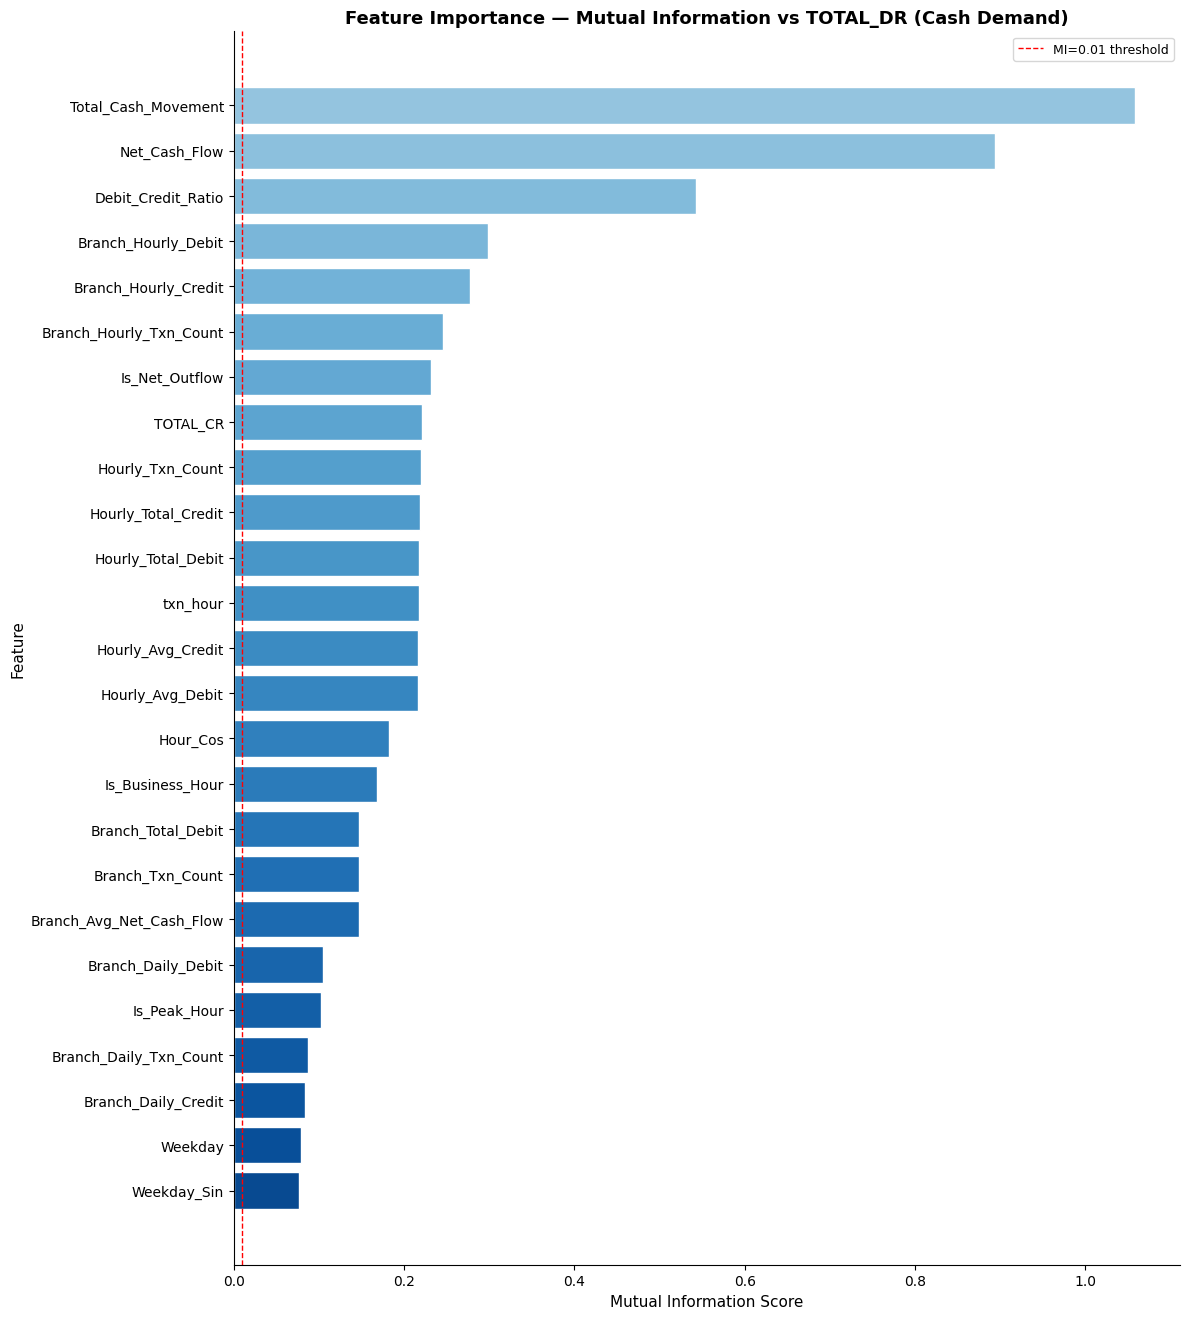

In [27]:
# ── 10.4 Mutual Information Visualization ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(6, len(mi_df) * 0.35)))

top_mi = mi_df.head(25)  # Show top 25
colors_mi = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_mi)))
bars = ax.barh(top_mi['Feature'][::-1], top_mi['Mutual_Info_Score'][::-1],
               color=colors_mi[::-1], edgecolor='white')

ax.set_title('Feature Importance — Mutual Information vs TOTAL_DR (Cash Demand)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Mutual Information Score')
ax.set_ylabel('Feature')
ax.axvline(x=0.01, color='red', linestyle='--', linewidth=1, label='MI=0.01 threshold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_plots/fe_01_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation — Mutual Information:**  
> - Features with high MI scores have strong (possibly non-linear) relationships with cash demand (`TOTAL_DR`).  
> - **Branch-level aggregates** typically score highest because branch identity is the strongest predictor of cash demand.  
> - **Hourly and daily aggregates** follow — confirming the importance of time-based patterns.  
> - Features with MI < 0.01 contribute negligible predictive information and can be dropped.

In [28]:
# ── 10.5 Select Final Feature Set ────────────────────────────────────────────
# Keep features with MI score > 0.01 (above noise threshold)
selected_features = mi_df[mi_df['Mutual_Info_Score'] > 0.01]['Feature'].tolist()

# Always include key identifying columns and target
must_include = ['start_date', 'tran_br_code', 'txn_hour', 'TOTAL_DR', 'TOTAL_CR']
final_features = must_include + [f for f in selected_features if f not in must_include]

print(f"📊 Feature Selection Summary:")
print(f"   Features before selection : {len(feature_cols)}")
print(f"   After Variance Threshold  : {len(high_var_cols)}")
print(f"   After Correlation Filter  : {len(remaining_after_corr)}")
print(f"   After MI Threshold (>0.01): {len(selected_features)}")
print(f"   Final features (+ ID cols): {len(final_features)}")
print(f"\n   Selected Features:")
for f in final_features:
    print(f"   - {f}")

📊 Feature Selection Summary:
   Features before selection : 52
   After Variance Threshold  : 50
   After Correlation Filter  : 39
   After MI Threshold (>0.01): 38
   Final features (+ ID cols): 41

   Selected Features:
   - start_date
   - tran_br_code
   - txn_hour
   - TOTAL_DR
   - TOTAL_CR
   - Total_Cash_Movement
   - Net_Cash_Flow
   - Debit_Credit_Ratio
   - Branch_Hourly_Debit
   - Branch_Hourly_Credit
   - Branch_Hourly_Txn_Count
   - Is_Net_Outflow
   - Hourly_Txn_Count
   - Hourly_Total_Credit
   - Hourly_Total_Debit
   - Hourly_Avg_Credit
   - Hourly_Avg_Debit
   - Hour_Cos
   - Is_Business_Hour
   - Branch_Total_Debit
   - Branch_Txn_Count
   - Branch_Avg_Net_Cash_Flow
   - Branch_Daily_Debit
   - Is_Peak_Hour
   - Branch_Daily_Txn_Count
   - Branch_Daily_Credit
   - Weekday
   - Weekday_Sin
   - Weekday_Cos
   - Is_Weekend
   - Month_Sin
   - Year
   - Month_Cos
   - Month
   - Daily_Txn_Count
   - Day
   - Monthly_Total_Debit
   - Monthly_Txn_Count
   - Daily_Total_De

---
## Step 11 — Display Final Dataset


In [29]:
# ── Build Final DataFrame ──────────────────────────────────────────────────────
df_final = df[final_features].copy()

print("╔══════════════════════════════════════════════════════════╗")
print("║           FINAL FEATURE-ENGINEERED DATASET               ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Shape          : {df_final.shape[0]:>7,} rows × {df_final.shape[1]:>3} columns         ║")
print(f"║  Memory Usage   : {df_final.memory_usage(deep=True).sum()/1024**2:>7.2f} MB                        ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  Original Columns     : start_date, txn_hour,            ║")
print("║                         tran_br_code, TOTAL_DR, TOTAL_CR ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Newly Created Features : {df_final.shape[1] - 5:>3} features added              ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║           FINAL FEATURE-ENGINEERED DATASET               ║
╠══════════════════════════════════════════════════════════╣
║  Shape          :  81,709 rows ×  41 columns         ║
║  Memory Usage   :   12.70 MB                        ║
╠══════════════════════════════════════════════════════════╣
║  Original Columns     : start_date, txn_hour,            ║
║                         tran_br_code, TOTAL_DR, TOTAL_CR ║
╠══════════════════════════════════════════════════════════╣
║  Newly Created Features :  36 features added              ║
╚══════════════════════════════════════════════════════════╝


In [30]:
# ── Final Shape & Column Overview ─────────────────────────────────────────────
print("📋 Final Columns & Data Types:")
for i, (col, dtype) in enumerate(df_final.dtypes.items(), 1):
    tag = '🆕' if col not in ['start_date','txn_hour','tran_br_code','TOTAL_DR','TOTAL_CR'] else '📌'
    print(f"   {tag} {i:>3}. {col:<45} | {str(dtype):<10}")

📋 Final Columns & Data Types:
   📌   1. start_date                                    | datetime64[ns]
   📌   2. tran_br_code                                  | category  
   📌   3. txn_hour                                      | uint8     
   📌   4. TOTAL_DR                                      | float32   
   📌   5. TOTAL_CR                                      | float32   
   🆕   6. Total_Cash_Movement                           | float32   
   🆕   7. Net_Cash_Flow                                 | float32   
   🆕   8. Debit_Credit_Ratio                            | float32   
   🆕   9. Branch_Hourly_Debit                           | float32   
   🆕  10. Branch_Hourly_Credit                          | float32   
   🆕  11. Branch_Hourly_Txn_Count                       | int64     
   🆕  12. Is_Net_Outflow                                | uint8     
   🆕  13. Hourly_Txn_Count                              | int64     
   🆕  14. Hourly_Total_Credit                           | float32   


In [31]:
# ── Preview of Final Dataset ───────────────────────────────────────────────────
print("\n📋 Preview of Final Dataset (First 10 rows):")
df_final.head(10)


📋 Preview of Final Dataset (First 10 rows):


,start_date,tran_br_code,txn_hour,TOTAL_DR,TOTAL_CR,Total_Cash_Movement,Net_Cash_Flow,Debit_Credit_Ratio,Branch_Hourly_Debit,Branch_Hourly_Credit,Branch_Hourly_Txn_Count,Is_Net_Outflow,Hourly_Txn_Count,Hourly_Total_Credit,Hourly_Total_Debit,Hourly_Avg_Credit,Hourly_Avg_Debit,Hour_Cos,Is_Business_Hour,Branch_Total_Debit,...,Branch_Avg_Net_Cash_Flow,Branch_Daily_Debit,Is_Peak_Hour,Branch_Daily_Txn_Count,Branch_Daily_Credit,Weekday,Weekday_Sin,Weekday_Cos,Is_Weekend,Month_Sin,Year,Month_Cos,Month,Daily_Txn_Count,Day,Monthly_Total_Debit,Monthly_Txn_Count,Daily_Total_Debit,Daily_Total_Credit,Daily_Net_Cash_Flow
0,2025-12-01,104,17,"52,041,400.0000","55,380,056.0000","107,421,456.0000","3,338,656.0000",0.9397,"14,034,273.0000","13,522,964.0000",552,0,7368,"40,230,072,320.0000","50,916,851,712.0000","5,460,107.5000","6,910,539.0000",-0.2588,0,"74,641,178,624.0000",...,"-126,521.5391","116,258,736.0000",0,10,"121,649,512.0000",0,0.0000,1.0000,0,-0.0000,2025,1.0000,12,150,1,"16,368,400,384.0000",3314,"949,430,016.0000","895,837,248.0000","-53,592,736.0000"
1,2026-03-24,104,15,"52,041,400.0000","55,380,056.0000","107,421,456.0000","3,338,656.0000",0.9397,"13,360,758.0000","10,441,775.0000",657,0,8390,"49,132,138,496.0000","56,288,882,688.0000","5,856,035.5000","6,709,044.5000",-0.7071,1,"74,641,178,624.0000",...,"-126,521.5391","231,977,824.0000",1,10,"191,959,952.0000",1,0.7818,0.6235,0,1.0000,2026,0.0000,3,141,24,"14,314,523,648.0000",2345,"1,101,869,952.0000","734,359,104.0000","-367,510,784.0000"
2,2024-02-02,104,12,"52,041,400.0000","55,380,056.0000","107,421,456.0000","3,338,656.0000",0.9397,"12,030,818.0000","13,562,067.0000",664,0,8980,"54,456,020,992.0000","42,279,788,544.0000","6,064,145.0000","4,708,217.0000",-1.0000,1,"74,641,178,624.0000",...,"-126,521.5391","160,237,296.0000",1,12,"174,547,056.0000",4,-0.4339,-0.9010,0,0.8660,2024,0.5000,2,157,2,"14,089,428,992.0000",2809,"874,701,440.0000","985,057,856.0000","110,356,416.0000"
3,2024-04-15,104,18,"52,041,400.0000","55,380,056.0000","107,421,456.0000","3,338,656.0000",0.9397,"10,231,433.0000","6,755,159.5000",461,0,3351,"12,949,701,632.0000","27,036,776,448.0000","3,864,429.0000","8,068,271.0000",-0.0000,0,"74,641,178,624.0000",...,"-126,521.5391","272,694,720.0000",0,11,"200,918,576.0000",0,0.0000,1.0000,0,0.8660,2024,-0.5000,4,140,15,"14,219,667,456.0000",2687,"1,217,442,560.0000","838,448,000.0000","-378,994,528.0000"
4,2026-03-25,104,15,"52,041,400.0000","15,516,110.0000","67,557,512.0000","-36,525,288.0000",3.3540,"13,360,758.0000","10,441,775.0000",657,1,8390,"49,132,138,496.0000","56,288,882,688.0000","5,856,035.5000","6,709,044.5000",-0.7071,1,"74,641,178,624.0000",...,"-126,521.5391","165,721,888.0000",1,10,"162,847,424.0000",2,0.9749,-0.2225,0,1.0000,2026,0.0000,3,133,25,"14,314,523,648.0000",2345,"572,691,648.0000","546,608,320.0000","-26,083,322.0000"
5,2026-03-25,104,14,"394,458.0000","55,380,056.0000","55,774,512.0000","54,985,600.0000",0.0071,"12,158,320.0000","11,112,811.0000",662,0,8916,"46,253,776,896.0000","43,337,203,712.0000","5,187,727.5000","4,860,610.5000",-0.8660,1,"74,641,178,624.0000",...,"-126,521.5391","165,721,888.0000",1,10,"162,847,424.0000",2,0.9749,-0.2225,0,1.0000,2026,0.0000,3,133,25,"14,314,523,648.0000",2345,"572,691,648.0000","546,608,320.0000","-26,083,322.0000"
6,2024-12-05,104,16,"52,041,400.0000","55,380,056.0000","107,421,456.0000","3,338,656.0000",0.9397,"17,472,898.0000","18,308,788.0000",606,0,7856,"58,310,389,760.0000","63,614,324,736.0000","7,422,402.0000","8,097,546.5000",-0.5000,1,"74,641,178,624.0000",...,"-126,521.5391","198,100,016.0000",0,10,"156,148,080.0000",3,0.4339,-0.9010,0,-0.0000,2024,1.0000,12,140,5,"16,575,425,536.0000",3161,"640,627,648.0000","707,761,920.0000","67,134,256.0000"
7,2024-03-07,104,12,"52,041,400.0000","55,380,056.0000","107,421,456.0000","3,338,656.0000",0.9397,"12,030,818.0000","13,562,067.0000",664,0,8980,"54,456,020,992.0000","42,279,788,544.0000","6,064,145.0000","4,708,217.0000",-1.0000,1,

In [32]:
# ── Statistics of Newly Created Features ──────────────────────────────────────
new_numeric_feats = [c for c in df_final.columns
                     if c not in ['start_date','txn_hour','tran_br_code','TOTAL_DR','TOTAL_CR','Time_Period']
                     and df_final[c].dtype in ['float32','float64','int16','int32','int64','uint8']]

print("\n📊 Summary Statistics — Newly Created Features:")
df_final[new_numeric_feats].describe().round(2)


📊 Summary Statistics — Newly Created Features:


,Total_Cash_Movement,Net_Cash_Flow,Debit_Credit_Ratio,Branch_Hourly_Debit,Branch_Hourly_Credit,Branch_Hourly_Txn_Count,Is_Net_Outflow,Hourly_Txn_Count,Hourly_Total_Credit,Hourly_Total_Debit,Hourly_Avg_Credit,Hourly_Avg_Debit,Hour_Cos,Is_Business_Hour,Branch_Total_Debit,Branch_Txn_Count,Branch_Avg_Net_Cash_Flow,Branch_Daily_Debit,Is_Peak_Hour,Branch_Daily_Txn_Count,Branch_Daily_Credit,Weekday,Weekday_Sin,Weekday_Cos,Is_Weekend,Month_Sin,Year,Month_Cos,Month,Daily_Txn_Count,Day,Monthly_Total_Debit,Monthly_Txn_Count,Daily_Total_Debit,Daily_Total_Credit,Daily_Net_Cash_Flow
count,"81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000","81,709.0000"
mean,"10,202,477.0000","-12,059.7900","169,142.2300","5,107,268.5000","5,095,208.5000",545.1000,0.4300,"8,068.2900","41,651,953,664.0000","39,816,970,240.0000","5,095,208.5000","5,107,268.5000",-0.7100,0.8400,"29,202,040,832.0000","5,488.4200","-12,059.7900","48,785,912.0000",0.5400,9.3500,"48,709,304.0000",2.1800,0.2700,-0.0900,0.0500,0.0400,"2,024.6600",0.0600,6.1800,136.3200,15.8400,"15,338,417,152.0000","3,025.9500","695,029,504.0000","693,066,048.0000","-1,963,462.8800"
std,"14,145,494.0000","8,555,070.0000","1,882,944.2500","3,409,005.0000","3,147,111.0000",102.7800,0.4900,"1,649.8800","14,003,649,536.0000","14,464,874,496.0000","1,389,070.8800","1,916,191.0000",0.3100,0.3700,"18,101,250,048.0000",495.3000,"59,941.9500","37,036,628.0000",0.5000,1.4300,"37,084,948.0000",1.5400,0.5800,0.7600,0.2200,0.7100,0.6600,0.7000,3.5800,24.7000,8.8300,"1,327,620,608.0000",350.1800,"179,199,584.0000","181,434,256.0000","71,097,216.0000"
min,4.0000,"-52,041,400.0000",0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,"3,146,409.0000",0.0000,"661,438.0600",-1.0000,0.0000,"12,358,500,352.0000","4,848.0000","-126,521.5400",0.0000,0.0000,1.0000,560.0000,0.0000,-0.9700,-0.9000,0.0000,-1.0000,"2,024.0000",-1.0000,1.0000,2.0000,1.0000,"2,468,904,960.0000",463.0000,0.0000,"1,728.0000","-553,259,456.0000"
25%,"2,006,000.0000","-1,721,800.0000",0.2200,"2,682,231.5000","2,940,944.0000",529.0000,0.0000,"7,856.0000","37,556,891,648.0000","29,772,974,080.0000","4,222,247.5000","4,002,133.0000",-0.9700,1.0000,"17,706,674,176.0000","5,134.0000","-34,516.3900","25,657,276.0000",0.0000,9.0000,"25,197,904.0000",1.0000,-0.4300,-0.9000,0.0000,-0.5000,"2,024.0000",-0.5000,3.0000,140.0000,8.0000,"14,635,589,632.0000","2,835.0000","604,408,064.0000","607,713,152.0000","-33,267,208.0000"
50%,"5,238,645.0000","240,520.0000",0.7800,"3,873,425.2500","4,268,332.0000",553.0000,0.0000,"8,474.0000","46,253,776,896.0000","42,279,788,544.0000","5,448,853.5000","4,708,217.0000",-0.8700,1.0000,"22,329,573,376.0000","5,298.0000","-11,979.3400","37,397,416.0000",1.0000,9.0000,"37,269,932.0000",2.0000,0.4300,-0.2200,0.0000,0.0000,"2,025.0000",0.0000,6.0000,143.0000,16.0000,"15,341,705,216.0000","3,099.0000","697,316,992.0000","697,839,296.0000","-1,807,144.0000"
75%,"13,076,556.0000","2,159,420.0000",2.0900,"7,137,804.5000","6,173,112.0000",596.0000,1.0000,"8,916.0000","49,132,138,496.0000","50,916,851,712.0000","5,856,035.5000","6,709,044.5000",-0.5000,1.0000,"29,002,334,208.0000","5,741.0000",-632.3200,"58,530,516.0000",1.0000,10.0000,"59,323,060.0000",4.0000,0.7800,0.6200,0.0000,0.8700,"2,025.0000",0.8700,9.0000,147.0000,24.0000,"15,885,341,696.0000","3,244.0000","803,253,952.0000","796,777,856.0000","33,158,760.0000"
max,"107,421,456.0000","55,380,056.0000","52,041,400.0000","17,472,898.0000","18,308,788.0000",664.0000,1.0000,"8,980.0000","58,310,389,760.0000","63,614,324,736.0000","7,422,402.0000","8,097,5

In [33]:
# ── Export Final Dataset ───────────────────────────────────────────────────────
df_final.to_csv('bank_cash_optimization_features.csv', index=False)
print("\n✅ Final feature-engineered dataset saved to: bank_cash_optimization_features.csv")
print(f"   File contains: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")


✅ Final feature-engineered dataset saved to: bank_cash_optimization_features.csv
   File contains: 81,709 rows × 41 columns


---
## Step 12 — Feature Engineering Summary

The table below documents every engineered feature, its business purpose, and its expected benefit to an ML cash optimization model.


### 📊 Feature Engineering Summary Table

| # | Feature | Category | Purpose | Expected ML Benefit |
|---|---------|----------|---------|---------------------|
| 1 | `Year` | Date | Captures annual growth trend | Enables year-over-year comparison |
| 2 | `Month` | Date | Captures monthly seasonality | Detects Eid, quarter-end cash spikes |
| 3 | `Day` | Date | Day of month (1–31) | Captures salary day and month-end effects |
| 4 | `Weekday` | Date | Day of week (0=Mon, 6=Sun) | Models weekly cash demand cycle |
| 5 | `Quarter` | Date | Financial quarter (1–4) | Captures quarterly reporting effects |
| 6 | `Week_Number` | Date | ISO week number | Captures bi-weekly payroll patterns |
| 7 | `Is_Weekend` | Date | Binary: 1=Saturday/Sunday | Separates branch vs ATM-driven demand |
| 8 | `Time_Period` | Time | Morning/Afternoon/Evening/Night | Encodes operational time windows |
| 9 | `Is_Business_Hour` | Time | Binary: 9AM–5PM flag | Filters teller vs ATM hours |
| 10 | `Is_Peak_Hour` | Time | Binary: 11AM–3PM peak flag | Marks highest debit demand window |
| 11 | `Hour_Sin` | Time | Sine encoding of txn_hour | Captures cyclical nature of time |
| 12 | `Hour_Cos` | Time | Cosine encoding of txn_hour | Prevents discontinuity at hour 23→0 |
| 13 | `Month_Sin` | Date | Sine encoding of Month | Captures cyclical seasonality |
| 14 | `Month_Cos` | Date | Cosine encoding of Month | Prevents Dec→Jan discontinuity |
| 15 | `Weekday_Sin` | Date | Sine encoding of Weekday | Cyclical weekly pattern |
| 16 | `Weekday_Cos` | Date | Cosine encoding of Weekday | Prevents Sun→Mon discontinuity |
| 17 | `Net_Cash_Flow` | Banking | CR − DR per record | Measures branch liquidity direction |
| 18 | `Total_Cash_Movement` | Banking | CR + DR per record | Measures total branch throughput |
| 19 | `Debit_Credit_Ratio` | Banking | DR / (CR + 1) | Classifies cash drain vs surplus branches |
| 20 | `Is_Net_Outflow` | Banking | Binary: DR > CR flag | Labels net outflow events |
| 21 | `Is_High_Value_DR` | Banking | Binary: DR > 99th pct | Flags large corporate/bulk withdrawals |
| 22 | `Is_High_Value_CR` | Banking | Binary: CR > 99th pct | Flags large deposit events |
| 23 | `Branch_Total_Debit` | Branch Agg | Total DR per branch | Encodes branch's long-run debit profile |
| 24 | `Branch_Total_Credit` | Branch Agg | Total CR per branch | Encodes branch's long-run credit profile |
| 25 | `Branch_Avg_Debit` | Branch Agg | Mean DR per branch | Typical withdrawal size for this branch |
| 26 | `Branch_Avg_Credit` | Branch Agg | Mean CR per branch | Typical deposit size for this branch |
| 27 | `Branch_Total_Cash` | Branch Agg | Sum of DR+CR per branch | Overall branch activity level |
| 28 | `Branch_Txn_Count` | Branch Agg | Total records per branch | Branch transaction frequency |
| 29 | `Branch_Avg_Net_Cash_Flow` | Branch Agg | Mean net flow per branch | Is branch typically surplus or deficit? |
| 30 | `Hourly_Total_Debit` | Hourly Agg | Total DR by hour | Baseline debit expectation per hour |
| 31 | `Hourly_Total_Credit` | Hourly Agg | Total CR by hour | Baseline credit expectation per hour |
| 32 | `Hourly_Cash_Movement` | Hourly Agg | Total DR+CR by hour | Hourly throughput baseline |
| 33 | `Hourly_Avg_Debit` | Hourly Agg | Mean DR by hour | Typical withdrawal at each hour |
| 34 | `Hourly_Avg_Credit` | Hourly Agg | Mean CR by hour | Typical deposit at each hour |
| 35 | `Hourly_Txn_Count` | Hourly Agg | Records per hour | Hour-level traffic baseline |
| 36 | `Daily_Total_Debit` | Daily Agg | Total DR per day | Day-level cash demand |
| 37 | `Daily_Total_Credit` | Daily Agg | Total CR per day | Day-level cash supply |
| 38 | `Daily_Cash_Movement` | Daily Agg | DR+CR per day | Total daily throughput |
| 39 | `Daily_Net_Cash_Flow` | Daily Agg | Net flow per day | Is this day net inflow or outflow? |
| 40 | `Daily_Txn_Count` | Daily Agg | Records per day | Daily activity volume |
| 41 | `Monthly_Total_Debit` | Monthly Agg | Total DR per month | Seasonal debit pattern |
| 42 | `Monthly_Total_Credit` | Monthly Agg | Total CR per month | Seasonal credit pattern |
| 43 | `Monthly_Cash_Movement` | Monthly Agg | DR+CR per month | Monthly throughput for seasonality |
| 44 | `Monthly_Txn_Count` | Monthly Agg | Records per month | Monthly volume |
| 45 | `Branch_Daily_Txn_Count` | Branch×Daily | Txns per branch per day | Granular branch-day activity |
| 46 | `Branch_Daily_Debit` | Branch×Daily | DR per branch per day | Branch-specific daily demand |
| 47 | `Branch_Daily_Credit` | Branch×Daily | CR per branch per day | Branch-specific daily supply |
| 48 | `Branch_Hourly_Txn_Count` | Branch×Hour | Txns per branch per hour | Most granular feature for intraday planning |
| 49 | `Branch_Hourly_Debit` | Branch×Hour | Avg DR per branch per hour | Branch-specific hourly demand |
| 50 | `Branch_Hourly_Credit` | Branch×Hour | Avg CR per branch per hour | Branch-specific hourly supply |


In [34]:
# ── Final Completion Banner ────────────────────────────────────────────────────
print("=" * 65)
print("     FEATURE ENGINEERING NOTEBOOK — EXECUTION COMPLETE")
print("=" * 65)
print(f"  Input  : 81,717 rows × 5 raw columns")
print(f"  Output : {df_final.shape[0]:,} rows × {df_final.shape[1]} feature-engineered columns")
print(f"  Saved  : bank_cash_optimization_features.csv")
print("")
print("  Feature Categories Created:")
print("    📅 Date Features         : Year, Month, Day, Weekday, Quarter,")
print("                              Week_Number, Is_Weekend")
print("    ⏰ Time Features          : Time_Period, Is_Business_Hour,")
print("                              Is_Peak_Hour, Hour_Sin/Cos")
print("    🏦 Banking Features       : Net_Cash_Flow, Total_Cash_Movement,")
print("                              Debit_Credit_Ratio, Is_Net_Outflow")
print("    🏢 Branch Aggregates      : Branch_Total/Avg DR/CR, Cash")
print("    🕐 Hourly Aggregates      : Hourly_Total/Avg DR/CR/Movement")
print("    📆 Daily Aggregates       : Daily_Total/Net DR/CR/Movement")
print("    📅 Monthly Aggregates     : Monthly_Total DR/CR/Movement")
print("    🔗 Cross Features         : Branch×Daily, Branch×Hour")
print("    🔄 Cyclical Encodings     : Month/Weekday Sin/Cos")
print("    ⚖️  Scaling               : RobustScaler on continuous features")
print("=" * 65)
print("  ✅ Dataset is ML-ready. Proceed to Model Development.")
print("=" * 65)

     FEATURE ENGINEERING NOTEBOOK — EXECUTION COMPLETE
  Input  : 81,717 rows × 5 raw columns
  Output : 81,709 rows × 41 feature-engineered columns
  Saved  : bank_cash_optimization_features.csv

  Feature Categories Created:
    📅 Date Features         : Year, Month, Day, Weekday, Quarter,
                              Week_Number, Is_Weekend
    ⏰ Time Features          : Time_Period, Is_Business_Hour,
                              Is_Peak_Hour, Hour_Sin/Cos
    🏦 Banking Features       : Net_Cash_Flow, Total_Cash_Movement,
                              Debit_Credit_Ratio, Is_Net_Outflow
    🏢 Branch Aggregates      : Branch_Total/Avg DR/CR, Cash
    🕐 Hourly Aggregates      : Hourly_Total/Avg DR/CR/Movement
    📆 Daily Aggregates       : Daily_Total/Net DR/CR/Movement
    📅 Monthly Aggregates     : Monthly_Total DR/CR/Movement
    🔗 Cross Features         : Branch×Daily, Branch×Hour
    🔄 Cyclical Encodings     : Month/Weekday Sin/Cos
    ⚖️  Scaling               : RobustScaler on